# Fase 5 — Señales Base (Z-score) y Backtest Benchmark

**Objetivo**: implementar la estrategia clasica de pairs trading basada en bandas Z-score como **benchmark** que el LSTM+RL deberan superar.

**Reglas**:
- **entry_short** (apostar a que el spread baja): `spread_z > +2.0` → vender Oro, comprar β·Plata
- **entry_long** (apostar a que el spread sube): `spread_z < -2.0` → comprar Oro, vender β·Plata
- **exit**: `|spread_z| < 0.5`
- **stop loss**: `|spread_z| > 4.0`

**Costos**: 5 bps por trade (comision + slippage). Posicion ±1 (notional fijo, sin Kelly).

**Metricas**: equity curve, retorno anualizado, Sharpe, Sortino, Max Drawdown, # trades, win rate.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path('data')
df = pd.read_parquet(DATA_DIR / 'features.parquet')
print(f'Datos: {df.shape}, rango {df.index.min().date()} -> {df.index.max().date()}')
df[['spread_kalman','spread_z','Gold','Silver','beta_kalman']].head()


Datos: (4051, 20), rango 2010-03-31 -> 2026-05-08


,spread_kalman,spread_z,Gold,Silver,beta_kalman
Date,,,,,
2010-03-31,-0.025920,-0.860797,1113.300049,17.511999,1.825147
2010-04-01,-0.038964,-1.209394,1125.099976,17.875999,1.820735
2010-04-05,-0.040544,-1.226119,1132.900024,18.104000,1.816134
2010-04-06,-0.014561,-0.483320,1135.099976,17.917000,1.814512
2010-04-07,-0.019469,-0.623021,1152.300049,18.184999,1.812322


## 5.1 Construccion de señales discretas
`signal_t ∈ {-1, 0, +1}` representa la posicion deseada SOBRE EL SPREAD:
- +1: long spread (esperamos que suba)
- -1: short spread (esperamos que baje)
- 0: flat

Implementacion: cuando entramos al limite, mantenemos hasta exit/stop.


In [2]:
ENTRY_Z = 2.0
EXIT_Z  = 0.5
STOP_Z  = 4.0

def zscore_signals(z, entry=ENTRY_Z, exit_=EXIT_Z, stop=STOP_Z):
    pos = np.zeros(len(z))
    cur = 0
    for i, v in enumerate(z.values):
        if cur == 0:
            if v > entry:   cur = -1
            elif v < -entry: cur = +1
        else:
            if abs(v) < exit_ or abs(v) > stop:
                cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index, name='signal')

df['signal'] = zscore_signals(df['spread_z'])
print(df['signal'].value_counts())
print(f'\n% del tiempo en posicion: {(df["signal"]!=0).mean()*100:.1f}%')


signal
 0.0    3422
 1.0     320
-1.0     309
Name: count, dtype: int64

% del tiempo en posicion: 15.5%


## 5.2 PnL del spread
Tradear el spread = posicion en Oro − β · posicion en Plata. El PnL diario en log-units es:

$$\text{PnL}_t = \text{signal}_{t-1} \cdot (\Delta\ln P_{oro,t} - \beta_{t-1} \cdot \Delta\ln P_{plata,t})$$

**Importante**: usamos `signal.shift(1)` para evitar look-ahead (la decision se toma en t pero el retorno corresponde a t+1).


In [3]:
COST_BPS = 5
cost_per_trade = COST_BPS / 10000.0  # 0.0005

ret_gold = df['Gold'].pct_change()
ret_silver = df['Silver'].pct_change()

# Posicion del dia anterior (anti look-ahead)
pos = df['signal'].shift(1).fillna(0)

# PnL bruto del spread
pnl_gross = pos * (ret_gold - df['beta_kalman'].shift(1) * ret_silver)

# Costos: pagamos cada vez que cambia la posicion
trades = pos.diff().abs().fillna(0)  # 0->1 = 1 trade, 1->-1 = 2 trades (en una pierna), etc.
# Aproximacion: cada cambio de unidad cuesta 2 * cost (entra y sale en 2 piernas) por simplicidad lo dejamos
costs = trades * cost_per_trade * 2  # 2 piernas (oro y plata)

pnl_net = pnl_gross - costs
df['pnl_net'] = pnl_net
df['equity'] = (1 + pnl_net).cumprod()

n_trades = int((trades > 0).sum())
print(f'N trades (cambios de posicion): {n_trades}')
print(f'Costos totales acumulados: {costs.sum()*100:.2f}%')


N trades (cambios de posicion): 258
Costos totales acumulados: 25.80%


## 5.3 Metricas de performance

In [4]:
def perf_metrics(pnl, equity, name='Strategy'):
    pnl = pnl.dropna()
    daily_mean = pnl.mean()
    daily_std = pnl.std()
    ann_ret = (1 + pnl).prod() ** (252/len(pnl)) - 1
    ann_vol = daily_std * np.sqrt(252)
    sharpe = (daily_mean / daily_std) * np.sqrt(252) if daily_std > 0 else 0
    downside = pnl[pnl < 0].std()
    sortino = (daily_mean / downside) * np.sqrt(252) if downside and downside > 0 else 0
    # Drawdown
    roll_max = equity.cummax()
    dd = equity/roll_max - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.inf
    # Win rate dia
    win_rate = (pnl > 0).mean()
    return {
        'Strategy': name,
        'Annual_Return': ann_ret, 'Annual_Vol': ann_vol,
        'Sharpe': sharpe, 'Sortino': sortino, 'Max_DD': max_dd, 'Calmar': calmar,
        'Win_Rate_Day': win_rate, 'N_Days': len(pnl)
    }

metrics_bench = perf_metrics(df['pnl_net'].dropna(), df['equity'].dropna(), 'Z-score Benchmark')
for k, v in metrics_bench.items():
    print(f'  {k:20s}: {v:.4f}' if isinstance(v,float) else f'  {k:20s}: {v}')


  Strategy            : Z-score Benchmark
  Annual_Return       : -0.0284
  Annual_Vol          : 0.1363
  Sharpe              : -0.1418
  Sortino             : -0.0743
  Max_DD              : -0.5725
  Calmar              : -0.0496
  Win_Rate_Day        : 0.0746
  N_Days              : 4050


## 5.4 Equity curve y drawdown

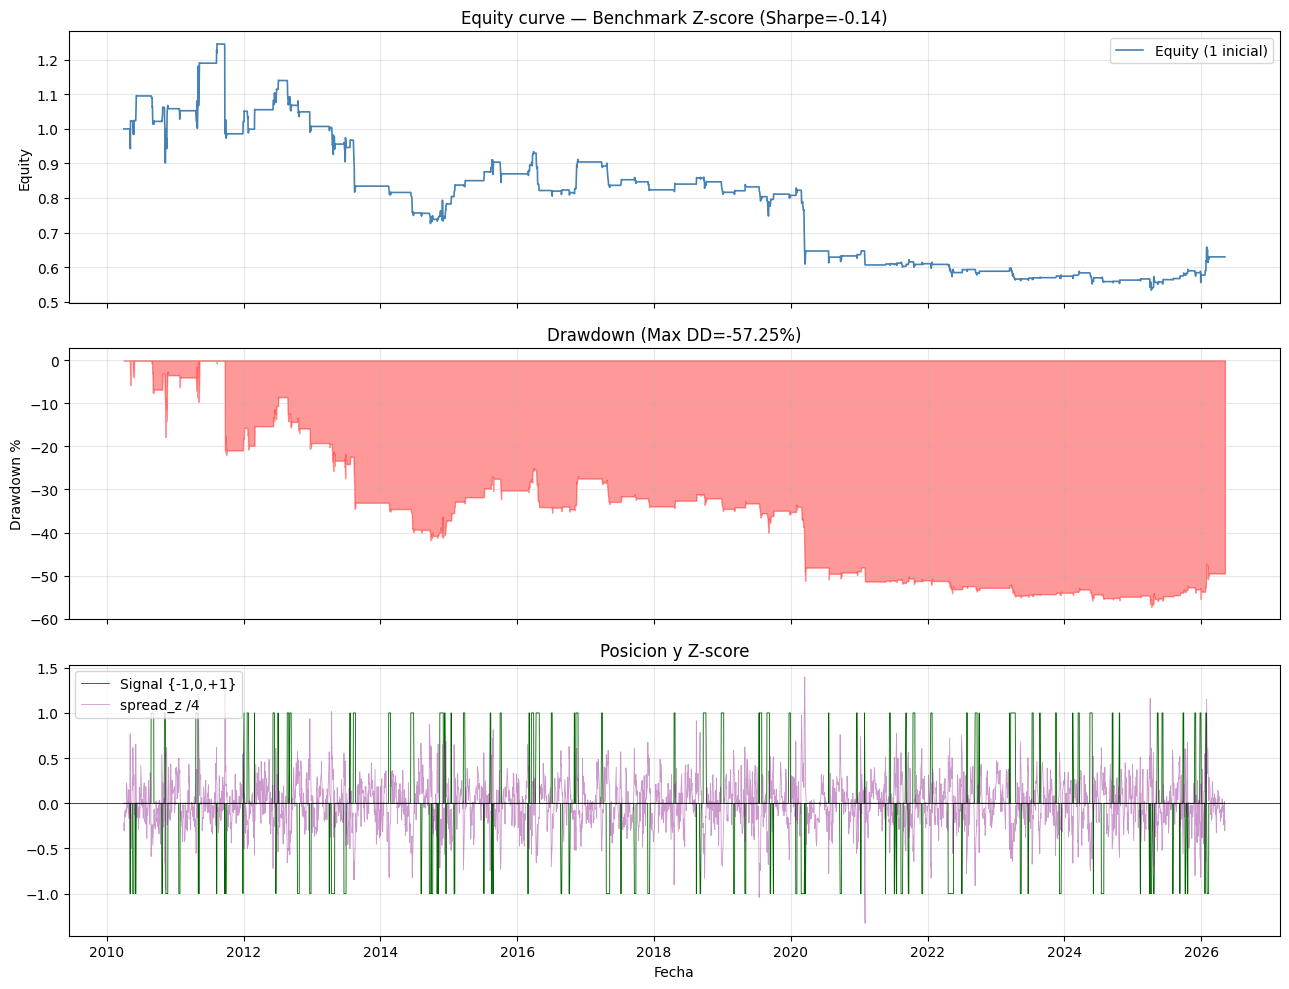

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(df.index, df['equity'], color='steelblue', lw=1.2, label='Equity (1 inicial)')
ax.set_title(f'Equity curve — Benchmark Z-score (Sharpe={metrics_bench["Sharpe"]:.2f})')
ax.set_ylabel('Equity'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
roll_max = df['equity'].cummax()
dd = (df['equity']/roll_max - 1) * 100
ax.fill_between(df.index, dd, 0, color='red', alpha=0.4)
ax.set_title(f'Drawdown (Max DD={metrics_bench["Max_DD"]*100:.2f}%)')
ax.set_ylabel('Drawdown %'); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(df.index, df['signal'], color='darkgreen', lw=0.6, label='Signal {-1,0,+1}')
ax.plot(df.index, df['spread_z']/4, color='purple', lw=0.6, alpha=0.4, label='spread_z /4')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Posicion y Z-score'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'benchmark_zscore.png', dpi=120)
plt.show()


## 5.5 Persistencia de señales y benchmark

In [6]:
signals_out = df[['spread_kalman','spread_z','beta_kalman','signal','pnl_net','equity']].copy()
signals_out.to_csv(DATA_DIR / 'signals_benchmark.csv')
pd.Series(metrics_bench).to_json(DATA_DIR / 'metrics_benchmark.json')
print(f'Guardado: data/signals_benchmark.csv y data/metrics_benchmark.json')
print(f'\nSharpe benchmark a superar: {metrics_bench["Sharpe"]:.3f}')


Guardado: data/signals_benchmark.csv y data/metrics_benchmark.json

Sharpe benchmark a superar: -0.142


## Conclusion Fase 5

Tenemos un **benchmark cuantificado** con la estrategia Z-score clasica. Esta es la barra que el LSTM y el agente RL **deben superar**. Si las metodologias mas sofisticadas no mejoran el Sharpe del benchmark, no agregan valor.

Si el Sharpe del benchmark ya es ≥ 1.5, eso ya cumple el objetivo del proyecto y el ML/RL es **mejora marginal**. Si es bajo o negativo, el ML tiene mucho margen para añadir valor.
